# Phase 1 — Lesson 6
## Resampling: Upsampling and Downsampling

This notebook teaches how to change the frequency of a time series using Pandas.

## Learning Objectives

By the end of this lesson, you should be able to:

1. Explain resampling.
2. Distinguish downsampling from upsampling.
3. Use `.resample()` with `.sum()`, `.mean()`, `.min()`, and `.max()`.
4. Use `.asfreq()`, `.ffill()`, `.bfill()`, and `.interpolate()` for upsampling.
5. Choose a resampling method based on the meaning of the data.

## 1. Concept

**Resampling** means changing the time frequency of a time series.

- **Downsampling:** higher frequency to lower frequency, such as daily to weekly.
- **Upsampling:** lower frequency to higher frequency, such as monthly to daily.

$$
\text{Resampling} = \text{Changing the time frequency of the data}
$$

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Create Daily Sales Data

In [2]:
data = {
    "Date": pd.date_range(start="2026-01-01", periods=28, freq="D"),
    "Sales": [
        100, 120, 110, 130, 150, 170, 160,
        105, 125, 115, 140, 165, 180, 175,
        120, 135, 130, 150, 170, 190, 185,
        125, 140, 145, 160, 180, 200, 195
    ]
}

sales_df = pd.DataFrame(data)
sales_df = sales_df.set_index("Date")
sales_df.head()

,Sales
Date,
2026-01-01,100
2026-01-02,120
2026-01-03,110
2026-01-04,130
2026-01-05,150


## 3. Plot the Original Daily Series

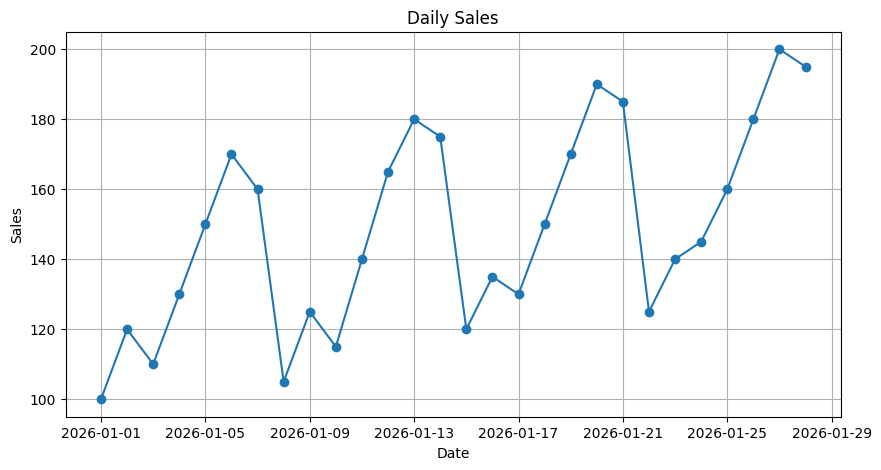

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(sales_df.index, sales_df["Sales"], marker="o")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Daily Sales")
plt.grid()
plt.show()

## 4. Downsampling: Daily to Weekly

Downsampling reduces the number of observations. It usually requires aggregation.

In [4]:
weekly_total = sales_df.resample("W").sum()
weekly_average = sales_df.resample("W").mean()
weekly_max = sales_df.resample("W").max()
weekly_min = sales_df.resample("W").min()

weekly_total

,Sales
Date,
2026-01-04,460
2026-01-11,965
2026-01-18,1055
2026-01-25,1115
2026-02-01,575


### Weekly Summary

In [5]:
weekly_summary = sales_df.resample("W").agg(["sum", "mean", "min", "max"])
weekly_summary

Sales                      
             sum        mean  min  max
Date                                  
2026-01-04   460  115.000000  100  130
2026-01-11   965  137.857143  105  170
2026-01-18  1055  150.714286  120  180
2026-01-25  1115  159.285714  125  190
2026-02-01   575  191.666667  180  200

### Plot Daily vs Weekly Average

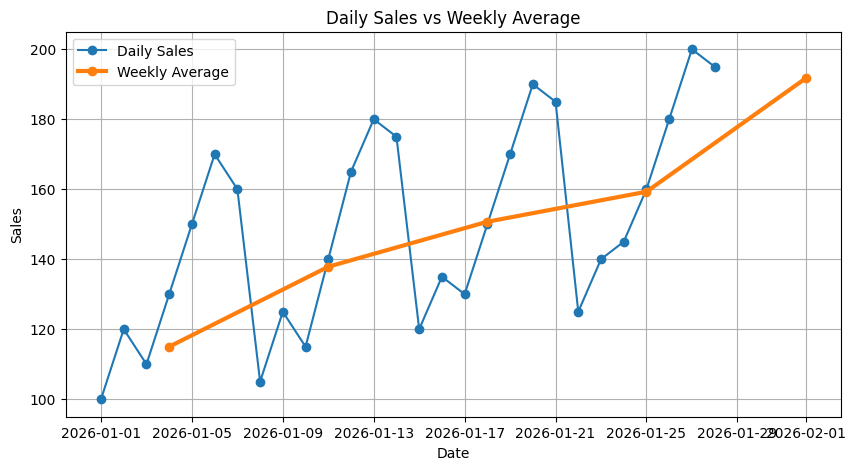

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(sales_df.index, sales_df["Sales"], marker="o", label="Daily Sales")
plt.plot(weekly_average.index, weekly_average["Sales"], marker="o", linewidth=3, label="Weekly Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Daily Sales vs Weekly Average")
plt.legend()
plt.grid()
plt.show()

## 5. Monthly Downsampling

Monthly total sales uses month-end frequency. In modern Pandas, use `ME` for month-end.

In [7]:
monthly_total = sales_df.resample("ME").sum()
monthly_average = sales_df.resample("ME").mean()

monthly_total

,Sales
Date,
2026-01-31,4170


## 6. Upsampling: Monthly to Daily

Upsampling increases the number of timestamps. New timestamps usually contain missing values first.

In [8]:
monthly_data = {
    "Date": pd.date_range(start="2026-01-01", periods=6, freq="MS"),
    "Visitors": [1000, 1200, 1100, 1500, 1700, 1900]
}

monthly_df = pd.DataFrame(monthly_data).set_index("Date")
monthly_df

,Visitors
Date,
2026-01-01,1000
2026-02-01,1200
2026-03-01,1100
2026-04-01,1500
2026-05-01,1700
2026-06-01,1900


In [9]:
daily_df = monthly_df.resample("D").asfreq()
daily_df.head(10)

,Visitors
Date,
2026-01-01,1000.0
2026-01-02,NaN
2026-01-03,NaN
2026-01-04,NaN
2026-01-05,NaN
2026-01-06,NaN
2026-01-07,NaN
2026-01-08,NaN
2026-01-09,NaN


## 7. Fill Methods for Upsampling

In [10]:
daily_ffill = monthly_df.resample("D").ffill()
daily_bfill = monthly_df.resample("D").bfill()
daily_interpolated = monthly_df.resample("D").asfreq().interpolate()

daily_ffill.head(10)

,Visitors
Date,
2026-01-01,1000
2026-01-02,1000
2026-01-03,1000
2026-01-04,1000
2026-01-05,1000
2026-01-06,1000
2026-01-07,1000
2026-01-08,1000
2026-01-09,1000


### Plot Forward Fill vs Interpolation

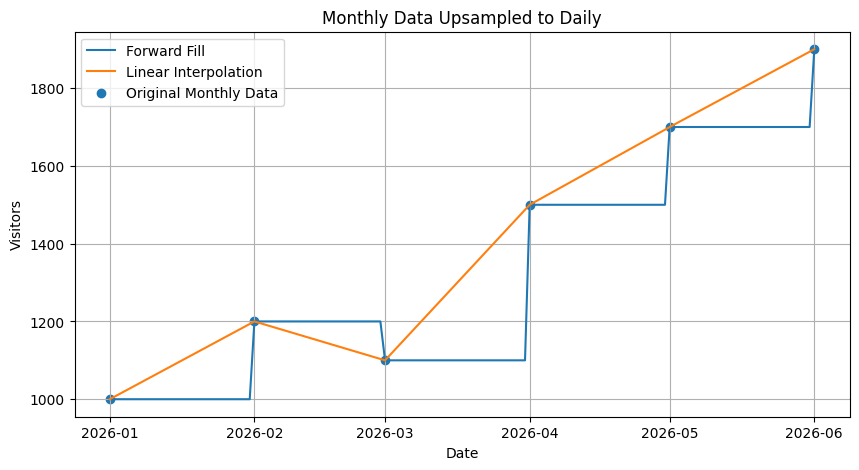

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(daily_ffill.index, daily_ffill["Visitors"], label="Forward Fill")
plt.plot(daily_interpolated.index, daily_interpolated["Visitors"], label="Linear Interpolation")
plt.scatter(monthly_df.index, monthly_df["Visitors"], label="Original Monthly Data")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.title("Monthly Data Upsampled to Daily")
plt.legend()
plt.grid()
plt.show()

## 8. Rule for Choosing the Method

Do not choose a method only because the graph looks better. Choose the method based on what the variable means.

- Sales/revenue totals: often use `.sum()` when downsampling.
- Temperature: often use `.mean()` when downsampling.
- Prices/rates that remain valid until changed: often use `.ffill()` when upsampling.
- Smooth physical processes: interpolation may be reasonable.

Interpolated values are estimates, not real observations.

## 9. Coding Exercise

In [12]:
practice_data = {
    "Date": pd.date_range(start="2026-04-01", periods=21, freq="D"),
    "Visitors": [
        90, 95, 100, 110, 150, 170, 160,
        105, 108, 115, 125, 155, 185, 175,
        120, 130, 135, 145, 165, 190, 180
    ]
}

practice_df = pd.DataFrame(practice_data).set_index("Date")
practice_df.head()

,Visitors
Date,
2026-04-01,90
2026-04-02,95
2026-04-03,100
2026-04-04,110
2026-04-05,150


In [13]:
# Weekly total, average, and maximum
weekly_total_visitors = practice_df.resample("W").sum()
weekly_average_visitors = practice_df.resample("W").mean()
weekly_max_visitors = practice_df.resample("W").max()

weekly_total_visitors

,Visitors
Date,
2026-04-05,545
2026-04-12,938
2026-04-19,1055
2026-04-26,370


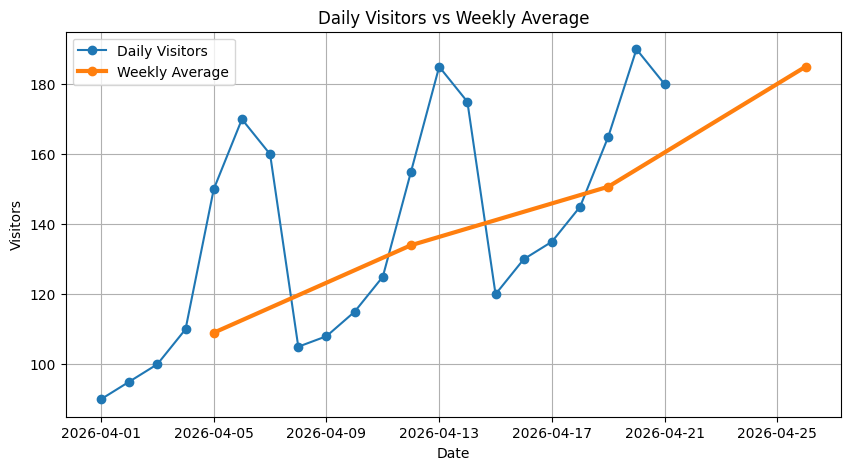

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(practice_df.index, practice_df["Visitors"], marker="o", label="Daily Visitors")
plt.plot(weekly_average_visitors.index, weekly_average_visitors["Visitors"], marker="o", linewidth=3, label="Weekly Average")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.title("Daily Visitors vs Weekly Average")
plt.legend()
plt.grid()
plt.show()

## 10. Final Practice Task

Use the `demand_data` below. Upsample it from monthly to daily, compare forward fill with interpolation, and explain which method you would choose.

In [15]:
demand_data = {
    "Date": pd.date_range(start="2026-01-01", periods=8, freq="MS"),
    "Demand": [500, 550, 530, 600, 650, 700, 680, 750]
}

demand_df = pd.DataFrame(demand_data).set_index("Date")

daily_demand_nan = demand_df.resample("D").asfreq()
daily_demand_ffill = demand_df.resample("D").ffill()
daily_demand_interpolated = demand_df.resample("D").asfreq().interpolate()

daily_demand_nan.head(10)

,Demand
Date,
2026-01-01,500.0
2026-01-02,NaN
2026-01-03,NaN
2026-01-04,NaN
2026-01-05,NaN
2026-01-06,NaN
2026-01-07,NaN
2026-01-08,NaN
2026-01-09,NaN


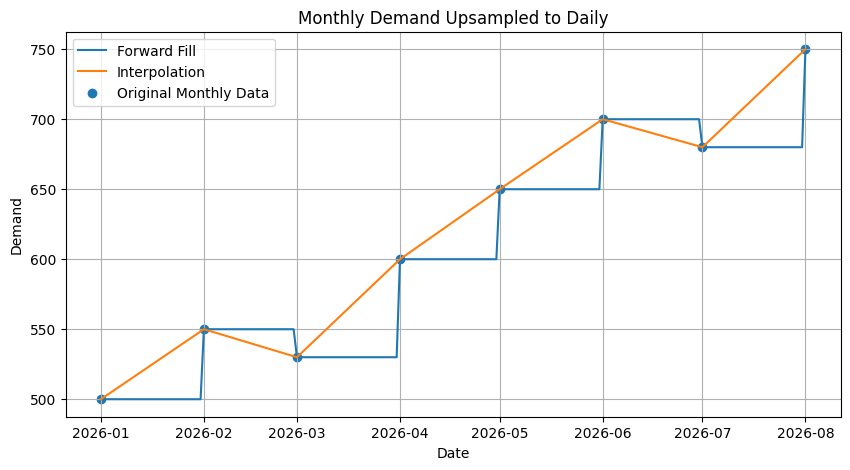

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(daily_demand_ffill.index, daily_demand_ffill["Demand"], label="Forward Fill")
plt.plot(daily_demand_interpolated.index, daily_demand_interpolated["Demand"], label="Interpolation")
plt.scatter(demand_df.index, demand_df["Demand"], label="Original Monthly Data")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("Monthly Demand Upsampled to Daily")
plt.legend()
plt.grid()
plt.show()

## Cheat Sheet

```python
# Daily to weekly total
df.resample("W").sum()

# Daily to weekly average
df.resample("W").mean()

# Daily to monthly total
df.resample("ME").sum()

# Monthly to daily with NaN
df.resample("D").asfreq()

# Monthly to daily forward fill
df.resample("D").ffill()

# Monthly to daily backward fill
df.resample("D").bfill()

# Monthly to daily interpolation
df.resample("D").asfreq().interpolate()
```